# Setup and Configs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from feature_visualization import FeatureAnalyzer
from dotenv import load_dotenv
from pathlib import Path
import wandb

In [2]:
# -- Configs -- #
expansion_factor = 32
_lambda = 1e-4
gpt_dim = 768
feature_analysis_count = 25
sampling = False

project_root = Path().resolve().parent.parent
load_dotenv(project_root / ".env")

sampling_suffix = '_sampling' if sampling else ''
HF_dataset_path = f"thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x_{_lambda}{sampling_suffix}"
table_name=f"hf_{expansion_factor}x_{str(_lambda).replace(".", "_")}_full{sampling_suffix}"

feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_dataset_path,
        db_name = str(project_root / "sae_feature_activations"),
        expansion_factor = expansion_factor
    )

feature_analyzer.create_features_table(table_name = table_name)
feature_analyzer.build_vocab_table()

# -- W&B Init -- #
_run_name = f"feature_analysis_{expansion_factor}x_{_lambda}" + ("_sampling" if sampling else "")
run = wandb.init(
    project="sae-for-monosemanticity",
    name=_run_name,
    config={
        "expansion_factor": expansion_factor,
        "_lambda": _lambda,
        "gpt_dim": gpt_dim,
        "feature_analysis_count": feature_analysis_count,
        "sampling": sampling,
    }
)

/Users/aditya/Desktop/projects/sae-monosemantic/src/evaluation/feature_visualization.py:810: UserWarning: Table 'hf_32x_0_0001_full' already exists. Skipping creation.
  warnings.warn(f"Table '{table_name}' already exists. Skipping creation.", UserWarning)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: adityaiyer-m (adityaiyer-m-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


# Batch Feature Analysis

Filter features by selectivity (mean activation / log(num activations + 1)), take top/bottom k, then batch-analyze all of them. Results are cached so individual inspection is instant.

In [3]:
min_activations = 10

feature_selective_ranked = feature_analyzer.rank_features_by_selectivity(
    table_name=table_name,
    min_activations=min_activations
)
top_k_df = feature_selective_ranked.head(feature_analysis_count)
bottom_k_df = feature_selective_ranked.tail(feature_analysis_count)

wandb.config.update({"min_activations": min_activations})

In [4]:
def analyze_feature(feature_id: int) -> dict:
    top_act_df = feature_analyzer.get_top_activations(table_name, int(feature_id), top_k=25)
    top_act_df = feature_analyzer.reconstruct_token_text(top_act_df)
    top_act_df = feature_analyzer.reconstruct_context_text(top_act_df)

    labeled_df = feature_analyzer.label_feature(top_act_df, use_groq = False)
    llm_label = labeled_df["llm_label"].iloc[0]
    llm_reasoning = labeled_df["llm_reasoning"].iloc[0]

    stats = feature_analyzer.get_activation_distribution(table_name, int(feature_id))
    cooc = feature_analyzer.get_co_occuring_features(table_name, int(feature_id))
    breakdown = feature_analyzer.get_token_type_breakdown(int(feature_id), table_name)

    raw_activations = feature_analyzer.query(
        f"SELECT activation_value FROM {table_name} WHERE feature_id = {int(feature_id)}"
    )["activation_value"].values

    return {
        "feature_id": feature_id,
        "llm_label": llm_label,
        "llm_reasoning": llm_reasoning,
        "top_activations": labeled_df,
        "activation_stats": stats,
        "co_occurring_features": cooc,
        "token_type_breakdown": breakdown,
        "raw_activations": raw_activations,
    }

In [5]:
def display_feature_result(r: dict, show_histogram: bool = True):
    print("=" * 80)
    print(f"Feature {r['feature_id']}: {r['llm_label']}")
    if "group" in r:
        print(f"Group: {r['group']}")
    print("=" * 80)

    print(f"\n--- LLM Reasoning ---\n{r['llm_reasoning']}")

    print("\n--- Top Activations ---")
    display(r["top_activations"])

    print("\n--- Activation Distribution Stats ---")
    for k, v in r["activation_stats"].items():
        print(f"  {k}: {v}")

    if show_histogram and len(r["raw_activations"]) > 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(r["raw_activations"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        mean_val = r["activation_stats"]["mean_activation_score"]
        median_val = r["activation_stats"]["median_activation_score"]
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3f}")
        ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.3f}")
        ax.set_title(f"Activation Distribution — Feature {r['feature_id']}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Count")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\n--- Co-occurring Features ---")
    display(r["co_occurring_features"])

    print("\n--- Token Type Breakdown ---")
    for prop, counts in r["token_type_breakdown"].items():
        print(f"  {prop}: {counts}")

### Run Batch Analysis

In [6]:
batch_features = (
    [(fid, "top-k") for fid in top_k_df["feature_id"]]
    + [(fid, "bottom-k") for fid in bottom_k_df["feature_id"]]
)

batch_results = []
for fid, group in tqdm(batch_features, desc="Analyzing features"):
    r = analyze_feature(fid)
    r["group"] = group
    batch_results.append(r)

# Build summary DataFrame
batch_summary_df = pd.DataFrame([
    {
        "feature_id": r["feature_id"],
        "group": r["group"],
        "llm_label": r["llm_label"],
        "mean_activation": r["activation_stats"]["mean_activation_score"],
        "median_activation": r["activation_stats"]["median_activation_score"],
        "std_activation": r["activation_stats"]["standard_deviatin_activation_scores"],
        "unique_tokens": r["activation_stats"]["unique_token_id_count"],
    }
    for r in batch_results
])

print(f"\nBatch complete: {len(batch_results)} features analyzed.")
display(batch_summary_df)

# --- W&B: batch summary table ---
wandb.log({"batch_summary": wandb.Table(dataframe=batch_summary_df)})

# --- W&B: per-feature data (top activations, co-occurring features, token breakdowns, histograms) ---
all_top_activations = []
all_co_occurring = []
all_token_breakdowns = []
feature_histograms = {}

for r in tqdm(batch_results, desc="Logging per-feature data to W&B"):
    fid = r["feature_id"]
    group = r["group"]

    # Top activations: assign group; feature_id already present in the df
    df = r["top_activations"].copy()
    df["feature_id"] = fid
    df["group"] = group
    all_top_activations.append(df)

    # Co-occurring features: drop token_ids (list column, not W&B-friendly)
    cooc = r["co_occurring_features"].copy()
    cooc["source_feature_id"] = fid
    cooc["group"] = group
    if "token_ids" in cooc.columns:
        cooc = cooc.drop(columns=["token_ids"])
    all_co_occurring.append(cooc)

    # Token type breakdown: flatten dict-of-dicts → rows
    for prop, counts in r["token_type_breakdown"].items():
        for value, count in counts.items():
            all_token_breakdowns.append({
                "feature_id": fid,
                "group": group,
                "property": prop,
                "value": str(value),
                "count": count,
            })

    # Per-feature activation histogram
    if len(r["raw_activations"]) > 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(r["raw_activations"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        mean_val = r["activation_stats"]["mean_activation_score"]
        median_val = r["activation_stats"]["median_activation_score"]
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3f}")
        ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.3f}")
        label_short = r["llm_label"][:40] + "..." if len(r["llm_label"]) > 40 else r["llm_label"]
        ax.set_title(f"Feature {fid}: {label_short}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Count")
        ax.legend()
        plt.tight_layout()
        feature_histograms[f"activation_hist/feature_{fid}"] = wandb.Image(fig)
        plt.close(fig)

combined_top_activations = pd.concat(all_top_activations, ignore_index=True)
wandb.log({"top_activations": wandb.Table(dataframe=combined_top_activations)})

non_empty_cooc = [df for df in all_co_occurring if not df.empty]
if non_empty_cooc:
    combined_co_occurring = pd.concat(non_empty_cooc, ignore_index=True)
    wandb.log({"co_occurring_features": wandb.Table(dataframe=combined_co_occurring)})

token_breakdown_df = pd.DataFrame(all_token_breakdowns)
wandb.log({"token_type_breakdown": wandb.Table(dataframe=token_breakdown_df)})

wandb.log(feature_histograms)

Analyzing features:   0%|          | 0/50 [00:00<?, ?it/s]


Batch complete: 50 features analyzed.


,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens
0,2587,top-k,Imperative action words in UI/headlines,582.895020,587.505432,15.136044,1874
1,1090,top-k,First-person singular pronoun “I”,569.714600,570.618774,7.331370,1873
2,19855,top-k,All-caps news dateline locations,494.237000,492.929718,10.455740,1873
3,16206,top-k,News outlet/source names,454.914001,458.689453,13.939964,1873
4,1593,top-k,Male first names in full names,443.699799,442.450348,7.510339,1873
5,17446,top-k,Capital V-initial words,443.442993,443.529602,12.120996,1873
6,10973,top-k,Photo gallery numbering and headers,9.419680,9.232510,1.006291,2
7,13639,top-k,POLYSEMANTIC,7.231596,7.252681,0.878491,1
8,2791,top-k,BBC article analysis heading,8.349857,8.231417,0.909424,1
9,18467,top-k,Corrupted quote separator token,14.913452,21.991219,8.269168,25


Logging per-feature data to W&B:   0%|          | 0/50 [00:00<?, ?it/s]

### Individual Feature Inspector
Change `inspect_idx` and re-run to browse through batch results — no LLM calls needed.

[1/50]
Feature 2587: Imperative action words in UI/headlines
Group: top-k

--- LLM Reasoning ---
The activations are mostly on capitalized imperative/action words that look like UI or headline lead-ins: **Play**, **Stop**, **Continue**, **Select**, **Remove**, **Enjoy**, **Jump**, **Control**, **Touch**, etc. They frequently appear at the start of snippets like buttons, links, ads, or article titles (“Continue Reading”, “Select a date”, “Play Ball”, “Stop working...”). A few noisy examples exist, but the dominant pattern is imperative/action verbs used in clickable interface or headline text.

--- Top Activations ---


,feature_id,activation_value,token_id,context_token_ids,chunk_id,token_text,context_text,context_string,llm_label,llm_reasoning
0,2587,614.478516,2633,"[45469, 11, 830, 17622, 468, 1775, 625, 5867, ...",36,joy,"[ 620, ,, 000, inhabitants, has, seen, ove...","620,000 inhabitants has seen over 300 homicid...",Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
1,2587,610.433350,10987,"[1561, 546, 17361, 11, 18933, 2057, 468, 17361...",44,Run,"[ talk, about, flavors, ,, Thai, food, ha...","talk about flavors, Thai food has flavors,"" s...",Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
2,2587,614.001160,11002,"[1180, 13, 314, 892, 685, 8134, 293, 74, 13165...",32,Play,"[ different, ., I, think, [, Ref, le, k, to...",different. I think [Reflektor]**Play** 02:45 ...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
3,2587,610.637695,11152,"[338, 286, 1919, 2056, 1943, 287, 281, 48033, ...",38,walk,"['s, of, social, media, success, in, an,...",'s of social media success in an infographic h...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
4,2587,614.001160,11002,"[22088, 37577, 11, 3306, 329, 34909, 7937, 13,...",7,Play,"[ ion, cannons, ,, necessary, for, disabli...","ion cannons, necessary for disabling ships. W...",Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
5,2587,614.001160,11002,"[2574, 4476, 18642, 447, 247, 82, 10183, 8530,...",24,Play,"[ El, Cap, itan, �, �, s, eastern, butt, re...",El Capitan��s eastern buttress.**Play** Ball:...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
6,2587,610.780945,15988,"[983, 3511, 0, 198, 198, 7120, 5184, 81, 14995...",14,Control,"[ game, yourself, !, \n, \n, Your, Av, r, lo...",game yourself!\n\nYour Avrlon Team**Control**...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
7,2587,610.797974,17563,"[575, 14057, 3418, 12874, 447, 247, 82, 4452, ...",10,Select,"[ Y, olo, County, Sheriff, �, �, s, Office,...",Yolo County Sheriff��s Office. No**Select** a...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
8,2587,610.797974,17563,"[1364, 1813, 326, 2744, 21468, 582, 12, 23505,...",19,Select,"[ left, given, that, Cor, rea, man, -, mar...",left given that Correa man-marked Busqu**Sele...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...
9,2587,611.315247,19485,"[32529, 318, 28389, 290, 460, 2465, 5922, 1633...",28,Stop,"[cigarettes, is, addictive, and, can, dam...",cigarettes is addictive and can damage develop...,Imperative action words in UI/headlines,The activations are mostly on capitalized impe...



--- Activation Distribution Stats ---
  mean_activation_score: 582.89501953125
  median_activation_score: 587.5054321289062
  standard_deviatin_activation_scores: 15.136043548583984
  activation_value_25th_percentile: 573.3018798828125
  activation_value_75th_percentile: 591.7966918945312
  unique_token_id_count: 1874


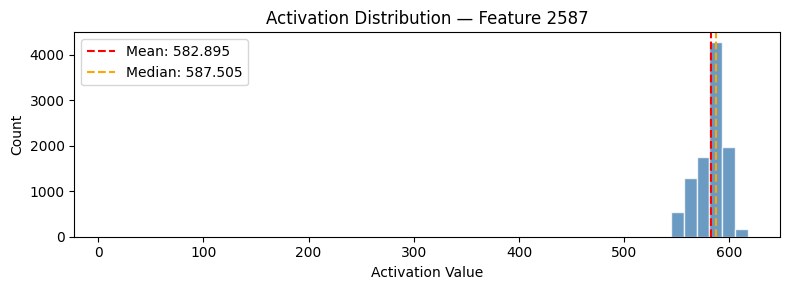


--- Co-occurring Features ---


,feature_id,co_occurrence_count,token_ids
0,1593,827,"[15645, 18254, 25515, 39401, 1722, 45580, 1281..."
1,17446,827,"[31, 27471, 35443, 7120, 28595, 38782, 10603, ..."
2,8791,827,"[19399, 40245, 274, 12, 29387, 23421, 37122, 7..."
3,16206,827,"[15645, 18254, 25515, 39401, 1722, 45580, 1281..."
4,2128,827,"[7191, 12, 19399, 274, 29387, 6104, 9527, 2380..."
...,...,...,...
1113,22091,1,[25]
1114,8426,1,[259]
1115,6269,1,[13]
1116,10139,1,[259]



--- Token Type Breakdown ---
  pos: {'PROPN': 290, 'NOUN': 241, 'X': 114, 'VERB': 102, 'ADJ': 70, 'ADP': 44, 'NUM': 32, 'ADV': 30, 'PRON': 16, 'PUNCT': 16, 'SPACE': 14, 'DET': 10, 'AUX': 9, 'CCONJ': 5, 'INTJ': 4, 'SCONJ': 3}
  ner: {'O': 813, 'ORG': 97, 'PERSON': 51, 'DATE': 9, 'PRODUCT': 7, 'CARDINAL': 6, 'WORK_OF_ART': 5, 'NORP': 4, 'GPE': 3, 'EVENT': 2, 'FAC': 1, 'QUANTITY': 1, 'TIME': 1}
  is_stop: {False: 945, True: 55}
  is_punct: {False: 991, True: 9}
  dep: {'compound': 210, '': 106, 'ROOT': 92, 'nsubj': 64, 'amod': 62, 'appos': 58, 'dobj': 58, 'pobj': 50, 'prep': 47, 'nmod': 38, 'punct': 38, 'advmod': 27, 'nummod': 26, 'dep': 21, 'npadvmod': 18, 'det': 12, 'ccomp': 11, 'conj': 10, 'attr': 9, 'aux': 6, 'acl': 6, 'poss': 5, 'cc': 5, 'intj': 4, 'relcl': 3, 'xcomp': 3, 'acomp': 3, 'advcl': 2, 'nsubjpass': 2, 'pcomp': 2, 'preconj': 1, 'meta': 1}
  subword_position: {'word_medial': 1000}
  is_numeric: {False: 1000}
  is_upper: {False: 1000}
  is_title: {True: 948, False: 52}
  is_w

In [7]:
inspect_idx = 0  # 0 to len(batch_results)-1

r = batch_results[inspect_idx]
print(f"[{inspect_idx + 1}/{len(batch_results)}]")
display_feature_result(r, show_histogram=True)

# Aggregate Analysis

### Monosemanticity Rate

In [8]:
polysemantic_count = sum(
    1 for r in batch_results if "POLYSEMANTIC" in r["llm_label"].upper()
)
total_count = len(batch_results)
monosemantic_rate = 1 - (polysemantic_count / total_count)

print(f"Monosemanticity Rate: {monosemantic_rate:.1%}")
print(f"  Polysemantic: {polysemantic_count}/{total_count}")
print(f"  Monosemantic: {total_count - polysemantic_count}/{total_count}")

group_metrics = {}
for group in ["top-k", "bottom-k"]:
    group_results = [r for r in batch_results if r["group"] == group]
    group_poly = sum(1 for r in group_results if "POLYSEMANTIC" in r["llm_label"].upper())
    rate = 1 - group_poly / len(group_results)
    print(f"  {group}: {len(group_results) - group_poly}/{len(group_results)} monosemantic "
          f"({rate:.1%})")
    group_metrics[f"monosemanticity_rate_{group.replace('-', '_')}"] = rate

wandb.log({
    "monosemanticity_rate": monosemantic_rate,
    "polysemantic_count": polysemantic_count,
    "monosemantic_count": total_count - polysemantic_count,
    **group_metrics,
})

Monosemanticity Rate: 78.0%
  Polysemantic: 11/50
  Monosemantic: 39/50
  top-k: 24/25 monosemantic (96.0%)
  bottom-k: 15/25 monosemantic (60.0%)


### Feature Density

,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens,feature_density
0,2587,top-k,Imperative action words in UI/headlines,582.895020,587.505432,15.136044,1874,5.758284e-05
1,1090,top-k,First-person singular pronoun “I”,569.714600,570.618774,7.331370,1873,5.757709e-05
2,19855,top-k,All-caps news dateline locations,494.237000,492.929718,10.455740,1873,5.757709e-05
3,16206,top-k,News outlet/source names,454.914001,458.689453,13.939964,1873,5.757709e-05
4,1593,top-k,Male first names in full names,443.699799,442.450348,7.510339,1873,5.757709e-05
5,17446,top-k,Capital V-initial words,443.442993,443.529602,12.120996,1873,5.757709e-05
6,10973,top-k,Photo gallery numbering and headers,9.419680,9.232510,1.006291,2,6.909250e-08
7,13639,top-k,POLYSEMANTIC,7.231596,7.252681,0.878491,1,5.757709e-08
8,2791,top-k,BBC article analysis heading,8.349857,8.231417,0.909424,1,9.212334e-08
9,18467,top-k,Corrupted quote separator token,14.913452,21.991219,8.269168,25,9.212334e-07


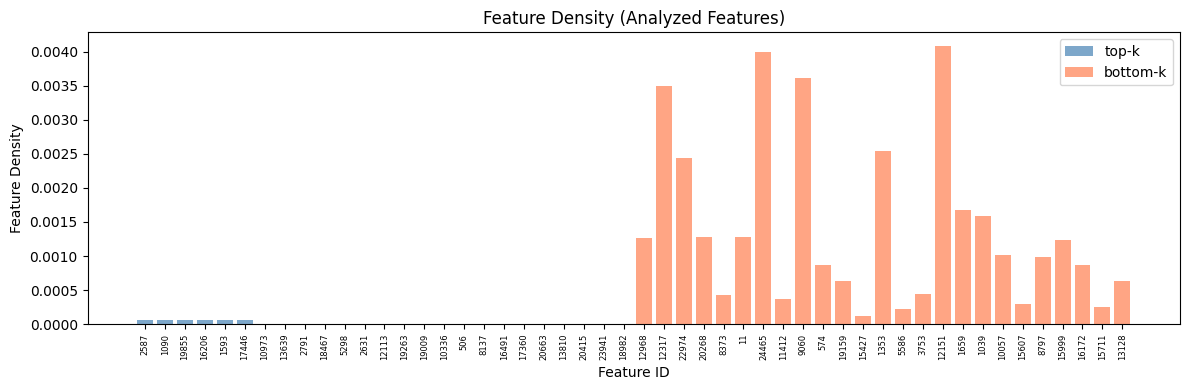

In [9]:
density_df = feature_analyzer.get_feature_density(table_name)

batch_summary_with_density = batch_summary_df.merge(density_df, on="feature_id", how="left")
display(batch_summary_with_density)

fig, ax = plt.subplots(figsize=(12, 4))
for group, color in [("top-k", "steelblue"), ("bottom-k", "coral")]:
    group_data = batch_summary_with_density[batch_summary_with_density["group"] == group]
    ax.bar(
        group_data["feature_id"].astype(str),
        group_data["feature_density"],
        color=color, alpha=0.7, label=group
    )
ax.set_xlabel("Feature ID")
ax.set_ylabel("Feature Density")
ax.set_title("Feature Density (Analyzed Features)")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()

wandb.log({
    "feature_density_chart": wandb.Image(fig),
    "batch_summary_with_density": wandb.Table(dataframe=batch_summary_with_density),
})
plt.show()

### Pairwise Feature Similarity

Computing similarity matrix:   0%|          | 0/50 [00:00<?, ?it/s]

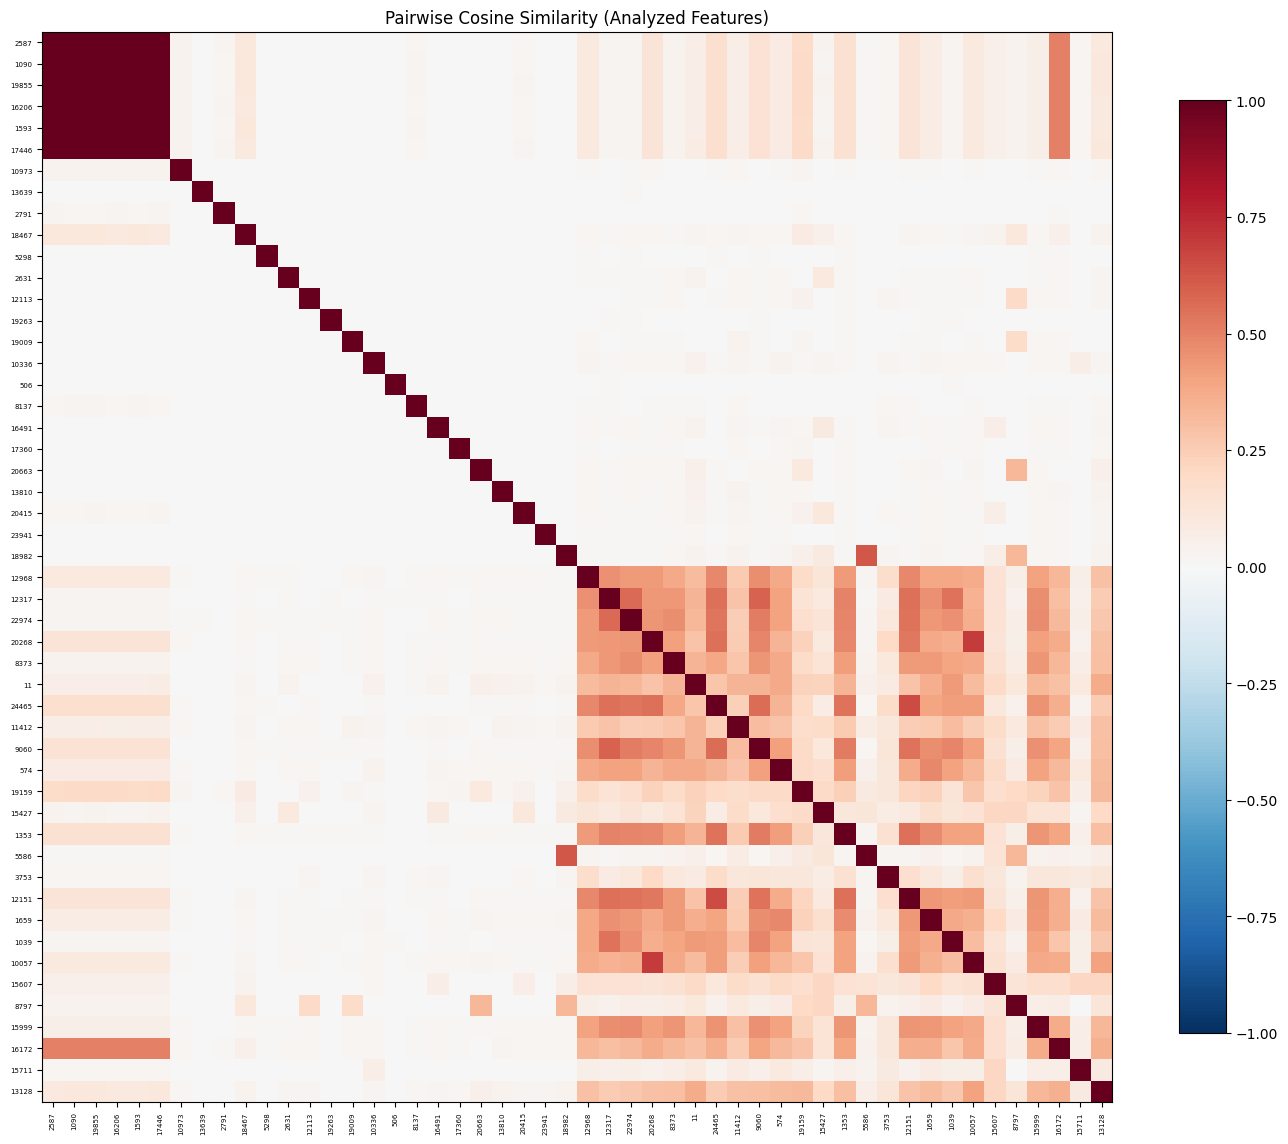

In [10]:
analyzed_feature_ids = [r["feature_id"] for r in batch_results]
n = len(analyzed_feature_ids)

sim_matrix = np.eye(n)
for i in tqdm(range(n), desc="Computing similarity matrix"):
    for j in range(i + 1, n):
        sim = feature_analyzer.feature_similarity_cosine_similarity(
            table_name, int(analyzed_feature_ids[i]), int(analyzed_feature_ids[j])
        )
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
labels = [str(fid) for fid in analyzed_feature_ids]
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_yticklabels(labels, fontsize=5)
ax.set_title("Pairwise Cosine Similarity (Analyzed Features)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

wandb.log({"pairwise_similarity_matrix": wandb.Image(fig)})
plt.show()

### Activation Distribution Grid

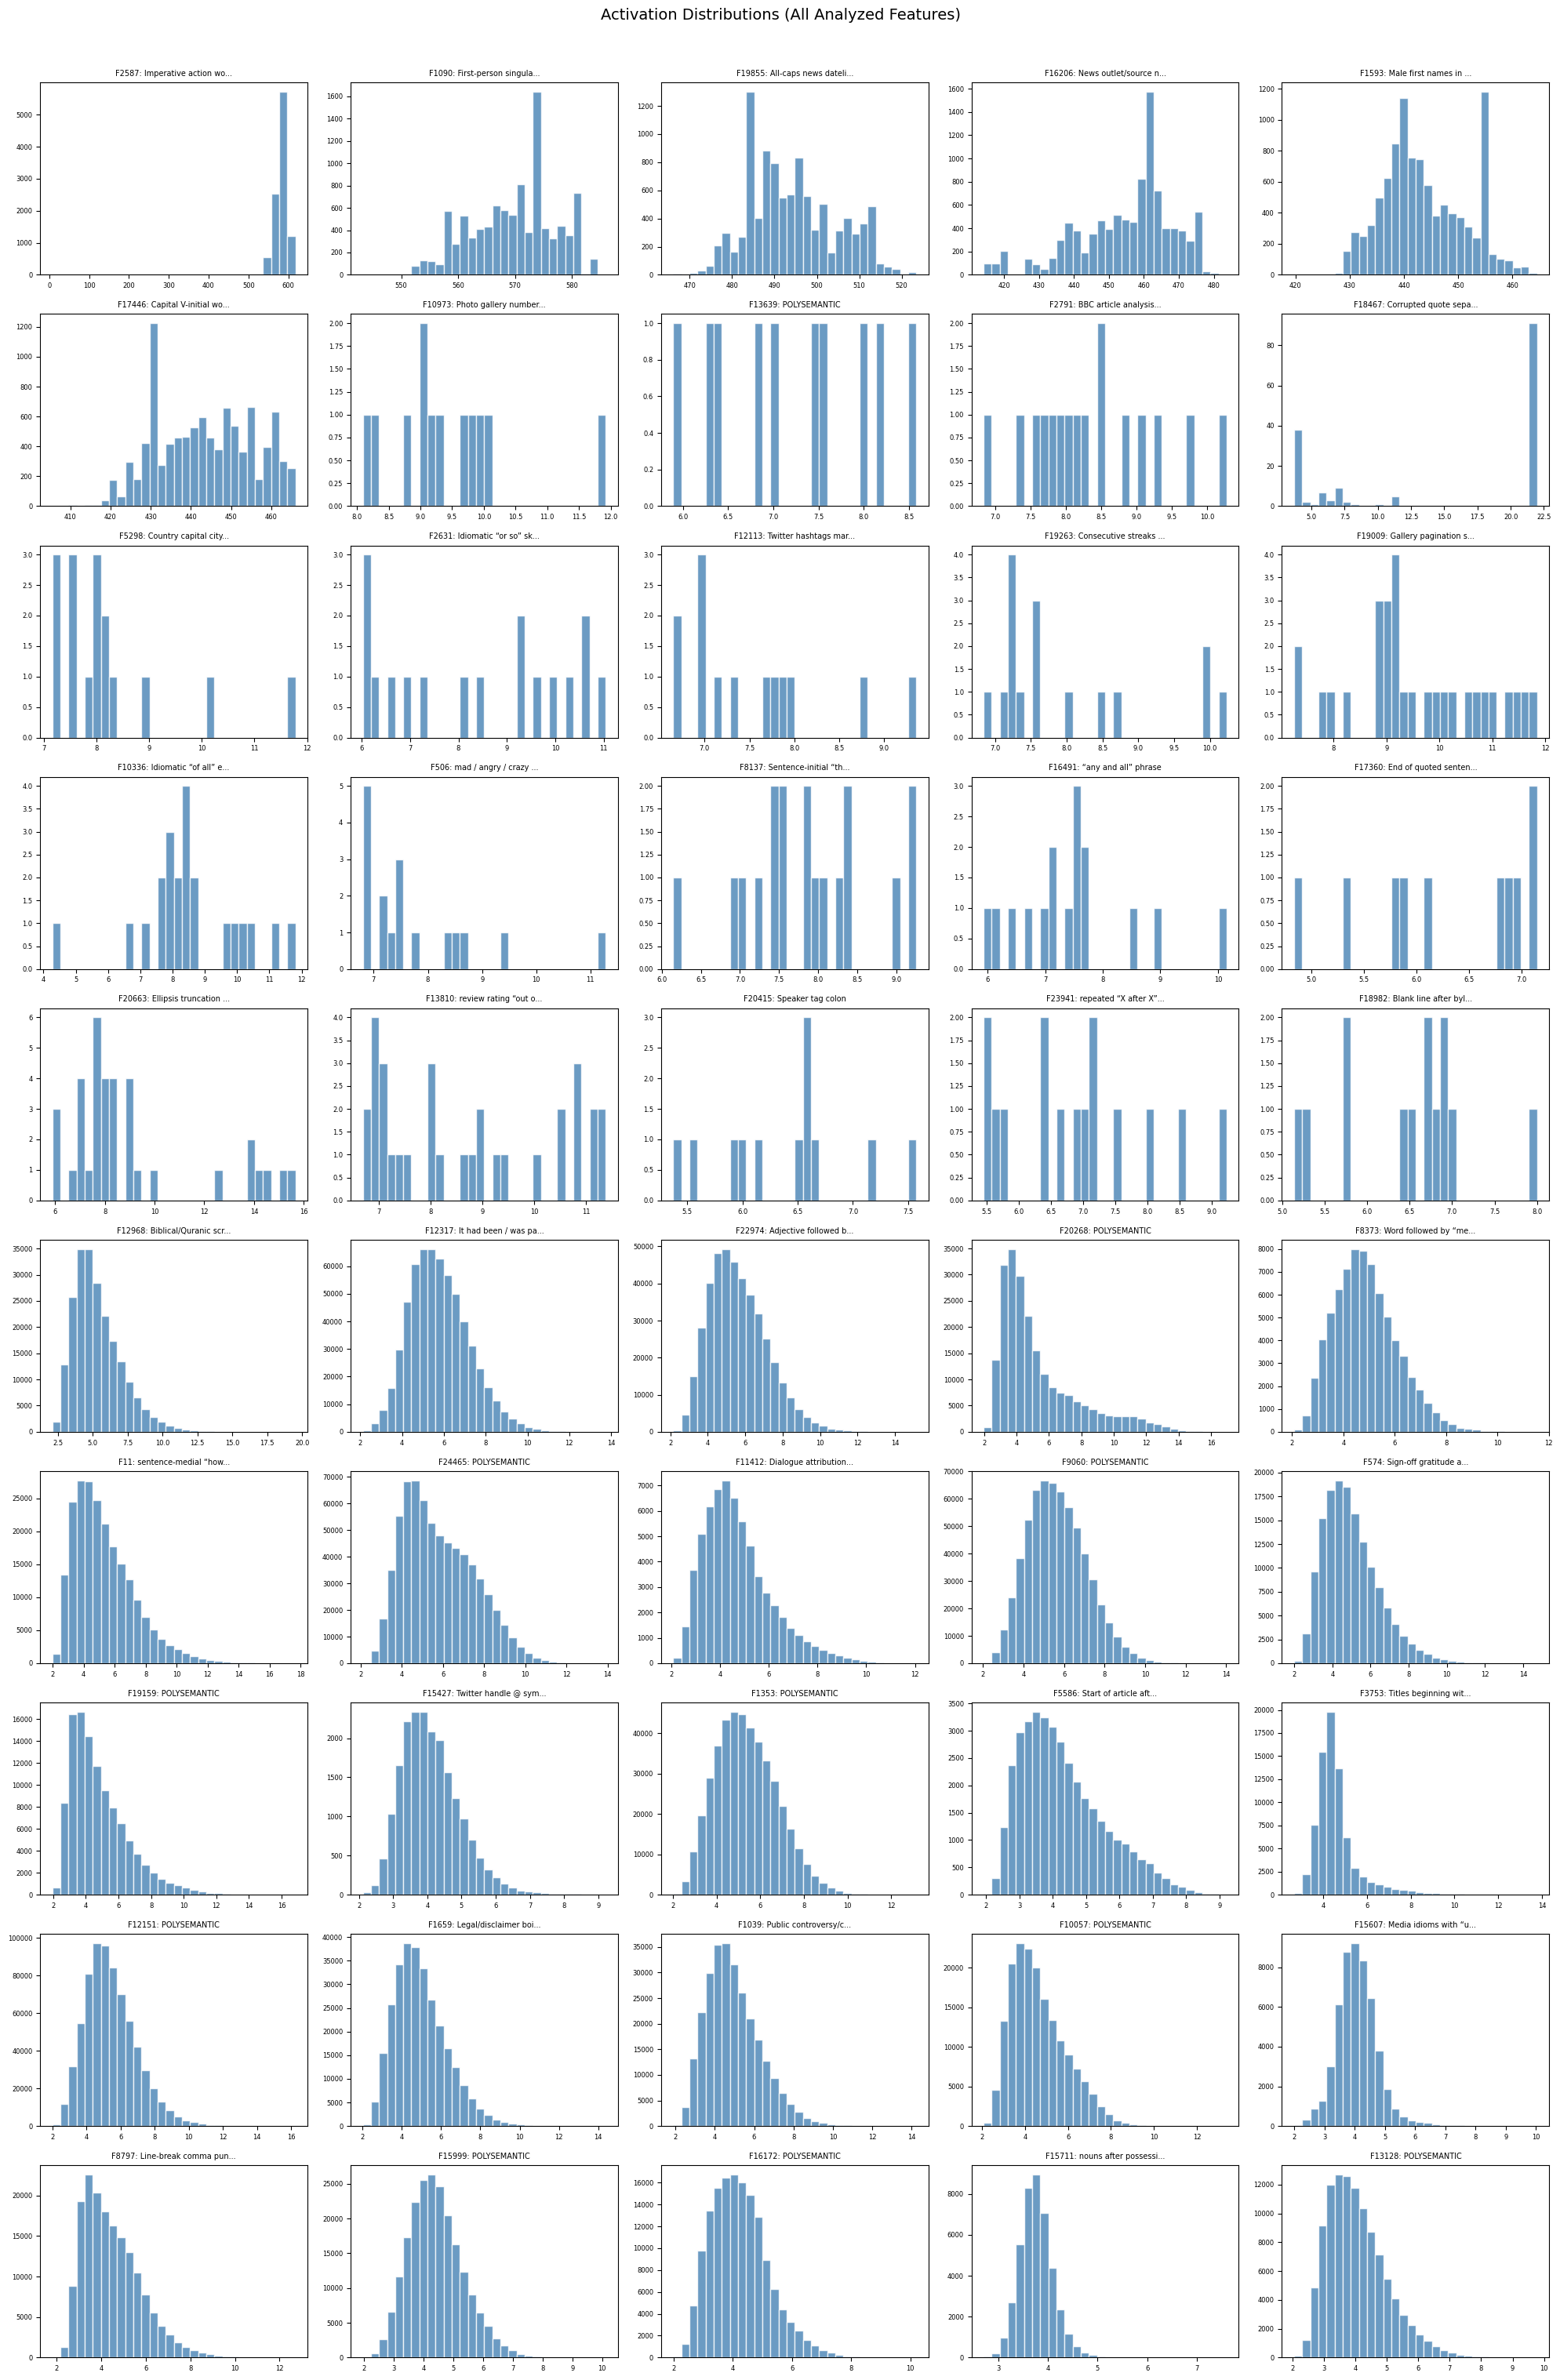

In [11]:
n_cols = 5
n_rows = (len(batch_results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, r in enumerate(batch_results):
    ax = axes[idx]
    ax.hist(r["raw_activations"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    label_short = r["llm_label"][:20] + "..." if len(r["llm_label"]) > 20 else r["llm_label"]
    ax.set_title(f"F{r['feature_id']}: {label_short}", fontsize=7)
    ax.tick_params(labelsize=6)

for idx in range(len(batch_results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Activation Distributions (All Analyzed Features)", fontsize=14, y=1.01)
plt.tight_layout()

wandb.log({"activation_distribution_grid": wandb.Image(fig)})
plt.show()

# Dead Feature Proportions

In [12]:
dead_df = feature_analyzer.get_dead_features()
wandb.log({"dead_features": wandb.Table(dataframe=dead_df)})
dead_df

,feature_id
0,3
1,5
2,6
3,10
4,13
...,...
8741,24556
8742,24560
8743,24561
8744,24568


In [13]:
dead_proportion = len(dead_df) / (expansion_factor * gpt_dim)
wandb.log({
    "dead_feature_proportion": dead_proportion,
    "dead_feature_count": len(dead_df),
})

wandb.finish()
dead_proportion

dead_feature_count,▁
dead_feature_proportion,▁
monosemantic_count,▁
monosemanticity_rate,▁
monosemanticity_rate_bottom_k,▁
monosemanticity_rate_top_k,▁
polysemantic_count,▁
dead_feature_count,8746
dead_feature_proportion,0.35588
monosemantic_count,39
monosemanticity_rate,0.78


0.3558756510416667